In [5]:
#Imports
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("data/iris.csv")

In [4]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
#Task - 1
np.random.seed(42)

data["location"] = np.random.randint(0, 2, size=len(data))

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species,location
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [8]:
data["location"].value_counts()

location
1    82
0    68
Name: count, dtype: int64

In [11]:
features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

X = data[features]
y = data["species"]
location = data["location"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, location_train, location_test = train_test_split(
    X,
    y,
    location,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42, max_depth=3)

model.fit(X_train,y_train)
predicted = model.predict(X_test)

print(accuracy_score(predicted, y_test))

0.9666666666666667


In [31]:
import joblib
import os

os.makedirs("models", exist_ok=True )
joblib.dump(model, 'models/model.joblib')

['models/model.joblib']

In [36]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [39]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "precision": lambda y_true, y_pred: precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "recall": lambda y_true, y_pred: recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    },
    y_true=y_test,
    y_pred=predicted,
    sensitive_features=location_test
)

In [40]:
print(metric_frame.by_group)

          accuracy  precision  recall
location                             
0           1.0000   1.000000  1.0000
1           0.9375   0.953125  0.9375


In [41]:
print("Overall:")
print(metric_frame.overall)

Overall:
accuracy     0.966667
precision    0.969697
recall       0.966667
dtype: float64


In [42]:
print("Difference between groups:")
print(metric_frame.difference())

Difference between groups:
accuracy     0.062500
precision    0.046875
recall       0.062500
dtype: float64


In [43]:
#Task-2
print("Ratio between groups:")
print(metric_frame.ratio())

Ratio between groups:
accuracy     0.937500
precision    0.953125
recall       0.937500
dtype: float64


In [45]:
import shap
import matplotlib.pyplot as plt

In [62]:
masker = shap.maskers.Independent(X, max_samples=150)
                                  
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [63]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, "shape") else len(shap_values))

<class 'numpy.ndarray'>
(150, 4, 3)


/var/tmp/ipykernel_3877/2310520985.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


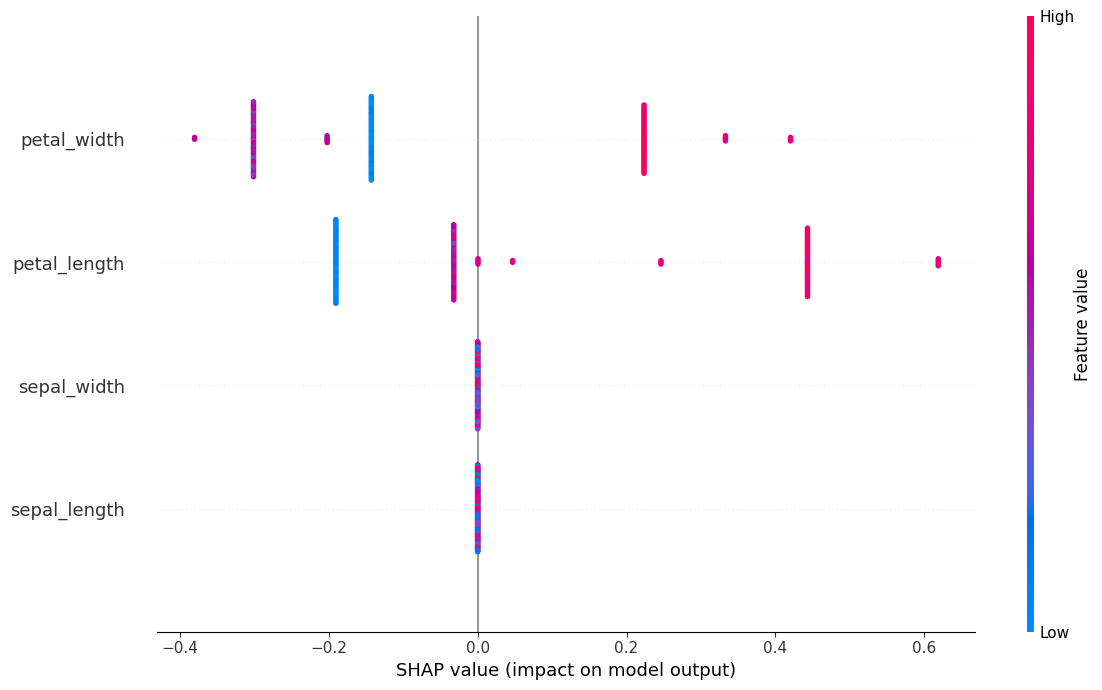

/var/tmp/ipykernel_3877/2310520985.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


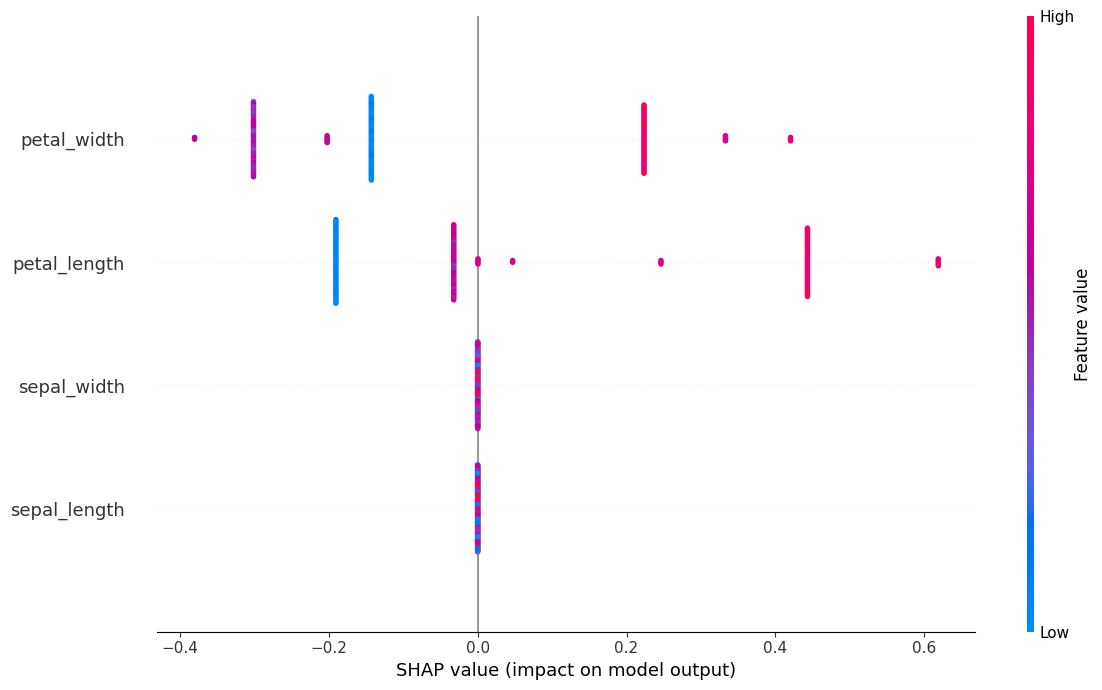

/var/tmp/ipykernel_3877/2310520985.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


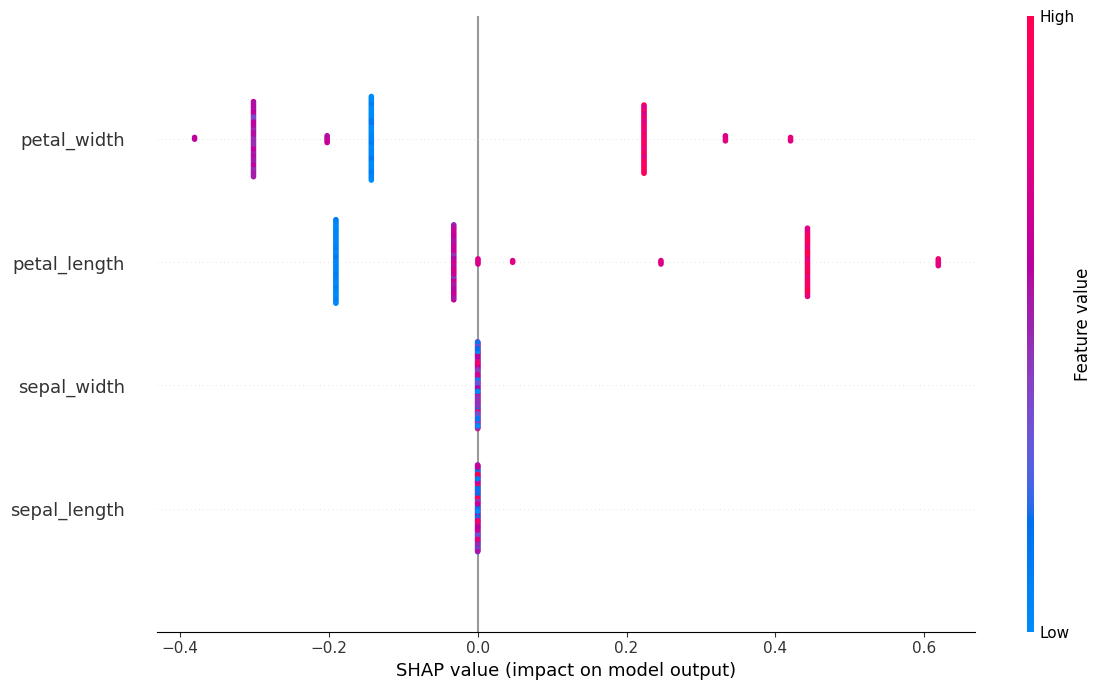

In [81]:
#Task - 3
class_names = ["setosa", "versicolor", "virginica"]

for class_index, class_name in enumerate(class_names):

            plt.figure(figsize=(12, 7))
            
            shap.summary_plot(
                shap_values[:, :, 2],
                X,
                plot_size=None,
                max_display=4
            )

In [82]:
X_prod = data.copy()

# Introduce drift in petal_length
X_prod["petal_length"] = X_prod["petal_length"] + 1.0

X_prod.head()

,sepal_length,sepal_width,petal_length,petal_width,species,location
0,5.1,3.5,2.4,0.2,setosa,0
1,4.9,3.0,2.4,0.2,setosa,1
2,4.7,3.2,2.3,0.2,setosa,0
3,4.6,3.1,2.5,0.2,setosa,0
4,5.0,3.6,2.4,0.2,setosa,0


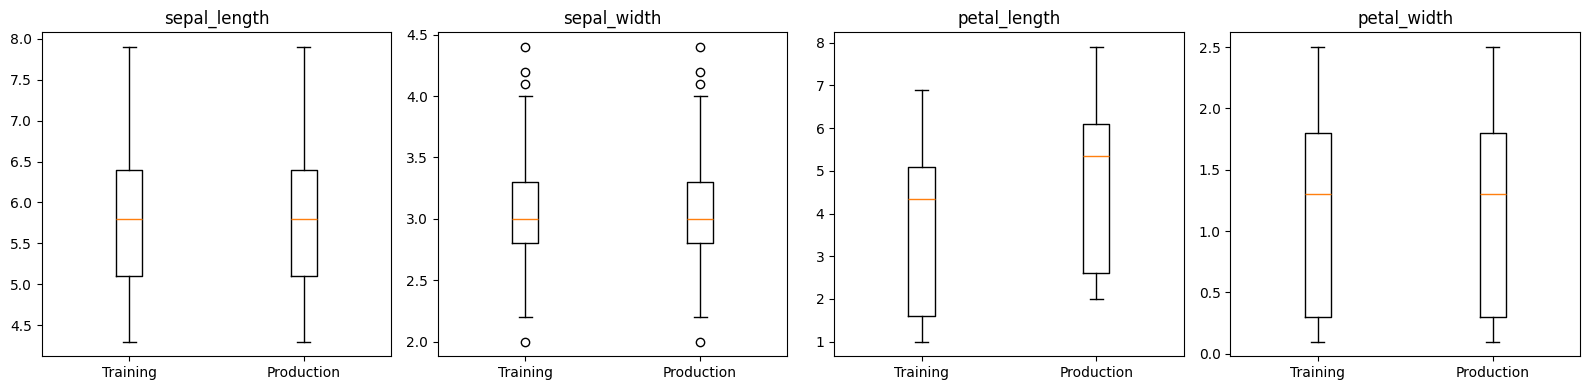

In [104]:
#Task - 4
features = data.columns

features = features.drop(["species", "location"])


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(features):
    axes[i].boxplot(
        [data[feature], X_prod[feature]],
        tick_labels=["Training", "Production"]
    )
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [105]:
from scipy.stats import ks_2samp

results = []

for feature in data.columns:
    statistic, p_value = ks_2samp(
        data[feature],
        X_prod[feature]
    )

    results.append({
        "feature": feature,
        "KS_statistic": statistic,
        "p_value": p_value
    })

drift_results = pd.DataFrame(results)

drift_results

,feature,KS_statistic,p_value
0,sepal_length,0.000000,1.000000e+00
1,sepal_width,0.000000,1.000000e+00
2,petal_length,0.333333,8.870018e-08
3,petal_width,0.000000,1.000000e+00
4,species,0.000000,1.000000e+00
5,location,0.000000,1.000000e+00


In [106]:
alpha = 0.05

In [107]:
drift_results["drift_detected"] = (
    drift_results["p_value"] < 0.05
)

drift_results

,feature,KS_statistic,p_value,drift_detected
0,sepal_length,0.000000,1.000000e+00,False
1,sepal_width,0.000000,1.000000e+00,False
2,petal_length,0.333333,8.870018e-08,True
3,petal_width,0.000000,1.000000e+00,False
4,species,0.000000,1.000000e+00,False
5,location,0.000000,1.000000e+00,False
